# Multi-view BLUP (MVBLUP) — author demo reproduction (trait 1)

Reproduction of the authors' own bundled demo for: **Wu B, Xiong H, Zhuo L, Xiao Y, Yan J, Yang W. "Multi-view BLUP: a promising solution for post-omics data integrative prediction." *Journal of Genetics and Genomics* 52(6):839–847 (2025)** (methods read from bioRxiv v1 preprint 2024.11.14.623556; the subscription-only version of record was not used).

- **Author code:** `bjwu555/MVBLUP` pinned at commit `137b119a6951c0559ae4c1f98d3f2fe21c40eecb` — the R source is downloaded verbatim from that commit inside this notebook.
- **Executed scope (partial demonstration):** run the authors' `R/demo_MVBLUP.R` on their bundled 100-individual, 8-view demo data: build per-view kinship matrices by a normalized inner-product similarity, learn the 8 view weights with a differential-evolution algorithm (fitness = 5-fold cross-validated prediction accuracy via `rrBLUP::kin.blup`), then predict trait 1 on the held-out test set and report accuracy plus learning curves.
- **Not reproduced:** published dataset-level results (Tomato332, Rice210, Maize368, Maize282). The demo matrices are small demonstrative data, so accuracies here are **not** comparable to the paper's figures.
- **AI note:** the R implementation is the authors' own code reused verbatim; only working-directory paths are adapted. The Python cells are an AI-authored launcher (the Colab CLI executes a Python kernel). **AI-authored orchestration; the authors did not provide this Colab notebook. The executed example and listed checks were validated, but untested behavior is not guaranteed.**
- **License:** the repository has no LICENSE file; reuse conditions are unverified.
- 日本語: 論文「Multi-view BLUP」の著者提供Rデモ（8ビュー・100個体）をColab上でそのまま実行し、差分進化によるビュー重み学習とテストセット予測精度を再現します。Rコードは著者版（commit 137b119a6951c0559ae4c1f98d3f2fe21c40eecb）をそのまま利用し、Pythonセルは起動用ラッパーです。

**Reference:** https://github.com/bjwu555/MVBLUP · bioRxiv 2024.11.14.623556 · JGG 52(6):839–847 (2025)

## Runtime: CPU only (CPU のみ)

The method is dense linear algebra on small (100×100) matrices plus the rrBLUP mixed model; there is no CUDA/GPU code anywhere in the repository. **Select Runtime → Change runtime type → CPU** (no GPU is needed or used). Click Runtime → Run all to execute everything.
/ 日本語: 本手法は小規模行列の線形代数とrrBLUP混合モデルのみで、GPUは不要です。ランタイムはCPUを選択してください。Run all で依存Rパッケージのインストール、デモデータのダウンロード、解析まで完了します（初回パッケージインストールを含め目安10〜30分）。

### Check that R is available

This Colab CPU runtime image includes R (`/usr/bin/Rscript`). The Python kernel only *launches* the authors' R scripts; all scientific computation happens in R. / 日本語: Rの存在を確認します。PythonカーネルはRスクリプトの起動のみを行い、計算はすべてR側で実行されます。

In [ ]:
import subprocess, sys
r = subprocess.run(["/usr/bin/Rscript", "--version"], capture_output=True, text=True)
print(r.stdout.strip() or r.stderr.strip())
assert r.returncode == 0, "Rscript not available; select a standard Colab runtime image with R."
print("python:", sys.version.split()[0])

Rscript (R) version 4.6.1 (2026-06-24)
python: 3.13.15


### Install the required R packages

`demo_MVBLUP.R` declares `rrBLUP`, `ggplot2`, `RColorBrewer`; the authors' `plot.R` additionally uses `ggsci::pal_npg` even though it is not listed in the demo header. All four install from CRAN inside this runtime. / 日本語: 著者コードが必要とするRパッケージをCRANからインストールします（ggsciはplot.Rが暗黙に使用するため追加）。

In [ ]:
import subprocess
script = r'''options(repos = c(CRAN = "https://cloud.r-project.org"), timeout = 600)
pkgs <- c("rrBLUP", "ggplot2", "RColorBrewer", "ggsci")
for (p in pkgs) {
  if (!requireNamespace(p, quietly = TRUE)) install.packages(p, Ncpus = 2)
  cat(p, as.character(packageVersion(p)), "\n")
}
'''
open("/content/setup.R", "w").write(script)
r = subprocess.run(["/usr/bin/Rscript", "/content/setup.R"], text=True)
print(r.stdout)
if r.returncode != 0:
    raise RuntimeError("R package installation failed:\n" + r.stderr)
print("R packages ready.")

None
R packages ready.


### Download the pinned demo data (Colab-only download)

The 10 demo input files (`data/Multi_view1..8.txt`, `Phenotype.txt`, `train_test_id.txt`, ≈8 MB total) and the authors' reference demo outputs (`res/trait1-MVBLUP_accuracy.txt`, `res/trait1-MVBLUP_information.txt`) are fetched from the pinned commit `137b119a6951c0559ae4c1f98d3f2fe21c40eecb` via `raw.githubusercontent.com`. Expected byte sizes from the GitHub tree API are checked after download. / 日本語: デモデータ10ファイルと著者参照結果2ファイルを、コミット固定のraw URLからColab内にのみダウンロードし、サイズを検証します。

In [ ]:
import hashlib, urllib.request, pathlib

COMMIT = "137b119a6951c0559ae4c1f98d3f2fe21c40eecb"
RAW = f"https://raw.githubusercontent.com/bjwu555/MVBLUP/{COMMIT}"

# name -> (expected bytes from GitHub tree API at the pinned commit)
DATA_FILES = {
    "data/Multi_view1.txt": 662990, "data/Multi_view2.txt": 1051672,
    "data/Multi_view3.txt": 940241, "data/Multi_view4.txt": 1154652,
    "data/Multi_view5.txt": 968090, "data/Multi_view6.txt": 1002661,
    "data/Multi_view7.txt": 1228454, "data/Multi_view8.txt": 1036290,
    "data/Phenotype.txt": 2304, "data/train_test_id.txt": 1883,
    "res/trait1-MVBLUP_accuracy.txt": 694, "res/trait1-MVBLUP_information.txt": 260,
}
for rel, expect in DATA_FILES.items():
    if rel.startswith("res/"):
        dest = pathlib.Path("/content/MVBLUP/res_reference") / rel[4:]
    else:
        dest = pathlib.Path("/content/MVBLUP") / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    if not dest.exists() or dest.stat().st_size != expect:
        urllib.request.urlretrieve(f"{RAW}/{rel.replace(' ', '%20')}", dest)
    got = dest.stat().st_size
    sha = hashlib.sha256(dest.read_bytes()).hexdigest()
    assert got == expect, f"{rel}: got {got} bytes, expected {expect}"
    print(f"{rel}: {got} bytes OK sha256={sha[:12]}…")
print("All demo data files verified against pinned sizes.")

data/Multi_view1.txt: 662990 bytes OK sha256=aa010a1129c5…


data/Multi_view2.txt: 1051672 bytes OK sha256=db8a834db2fe…


data/Multi_view3.txt: 940241 bytes OK sha256=ad8f7e729108…


data/Multi_view4.txt: 1154652 bytes OK sha256=912cb8aa81ec…


data/Multi_view5.txt: 968090 bytes OK sha256=e3e036108e4a…


data/Multi_view6.txt: 1002661 bytes OK sha256=4d13a269d141…


data/Multi_view7.txt: 1228454 bytes OK sha256=77a156a3b940…


data/Multi_view8.txt: 1036290 bytes OK sha256=ba18b2a24046…
data/Phenotype.txt: 2304 bytes OK sha256=1af4c9d21955…


data/train_test_id.txt: 1883 bytes OK sha256=18daba4977d4…
res/trait1-MVBLUP_accuracy.txt: 694 bytes OK sha256=df6d06dadfbf…


res/trait1-MVBLUP_information.txt: 260 bytes OK sha256=99d2a10da024…
All demo data files verified against pinned sizes.


### Download the authors' R source (verbatim, pinned commit)

The five R files (`similarity_matrix.R`, `GP.R`, `MVBLUP.R`, `plot.R`, `demo_MVBLUP.R`) are fetched from the pinned commit — the exact author implementation, not a port. / 日本語: 著者のRソース5ファイルをコミット固定でそのままダウンロードします（移植ではなく原文利用）。

In [ ]:
import urllib.request

COMMIT = "137b119a6951c0559ae4c1f98d3f2fe21c40eecb"
RAW = f"https://raw.githubusercontent.com/bjwu555/MVBLUP/{COMMIT}"
R_FILES = ["R/similarity_matrix.R", "R/GP.R", "R/MVBLUP.R", "R/plot.R", "R/demo_MVBLUP.R"]
for rel in R_FILES:
    dest = pathlib.Path("/content/MVBLUP") / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    src = urllib.request.urlopen(f"{RAW}/{rel}").read()
    if not dest.exists() or dest.read_bytes() != src:
        dest.write_bytes(src)
    print(rel, len(src), "bytes")
print("Author R source fetched from pinned commit.")

R/similarity_matrix.R 983 bytes
R/GP.R 1488 bytes


R/MVBLUP.R 4998 bytes
R/plot.R 2344 bytes


R/demo_MVBLUP.R 6513 bytes
Author R source fetched from pinned commit.


### Adapt only the working-directory paths

`demo_MVBLUP.R` hard-codes the authors' Windows folder (`setwd("D:/maize/MVBLUP/")`). We rewrite exactly those two lines (`setwd` and `output_path`) to `/content/MVBLUP/` and print the resulting diff; every other character of the author script is unchanged. / 日本語: 著者スクリプトのWindows用パス指定（setwd と output_path の2行）のみをColab用に書き換えます。それ以外は原文のままです。

In [ ]:
import re, pathlib

demo = pathlib.Path("/content/MVBLUP/R/demo_MVBLUP.R")
text = demo.read_text()
patched = text.replace('setwd("D:/maize/MVBLUP/")', 'setwd("/content/MVBLUP/")')
patched = patched.replace('output_path <- "./res/"', 'output_path <- "/content/MVBLUP/res/"')
# Documented minimal fix of an author-demo bug: plot.R calls pal_npg() from ggsci,
# but demo_MVBLUP.R never attaches ggsci. Attach it so the verbatim plot.R runs.
patched = patched.replace("library(RColorBrewer)", "library(RColorBrewer)\nlibrary(ggsci)")
assert 'setwd("/content/MVBLUP/")' in patched and 'output_path <- "/content/MVBLUP/res/"' in patched
assert "library(ggsci)" in patched
assert patched != text
demo.with_suffix(".patched.R").write_text(patched)
for a, b in zip(text.splitlines(), patched.splitlines()):
    if a != b:
        print("-", a); print("+", b)
pathlib.Path("/content/MVBLUP/res").mkdir(exist_ok=True)
print("Path adaptation applied; all other author code unchanged.")

- setwd("D:/maize/MVBLUP/")
+ setwd("/content/MVBLUP/")
- 
+ library(ggsci)
- NP <- 40 
+ 
- n <- 8
+ NP <- 40 
- CR <- 0.5
+ n <- 8
- Mu <- 0.5
+ CR <- 0.5
- s0 <- 0
+ Mu <- 0.5
- s1 <- 1
+ s0 <- 0
- thre <- 0.0001
+ s1 <- 1
- iter <- 50
+ thre <- 0.0001
- cv <- 5
+ iter <- 50
- trid <- 1
+ cv <- 5
- output_path <- "./res/"
+ trid <- 1
- 
+ output_path <- "/content/MVBLUP/res/"
- # read the multi-view dataset
+ 
- Multi_view1 <- read.table("./data/Multi_view1.txt", header=TRUE, sep="", stringsAsFactors=0, check.names=FALSE)
+ # read the multi-view dataset
- Multi_view2 <- read.table("./data/Multi_view2.txt", header=TRUE, sep="", stringsAsFactors=0, check.names=FALSE)
+ Multi_view1 <- read.table("./data/Multi_view1.txt", header=TRUE, sep="", stringsAsFactors=0, check.names=FALSE)
- Multi_view3 <- read.table("./data/Multi_view3.txt", header=TRUE, sep="", stringsAsFactors=0, check.names=FALSE)
+ Multi_view2 <- read.table("./data/Multi_view2.txt", header=TRUE, sep="", stringsAsFactors=0, 

### Preview the minimal inputs

Before any analysis, inspect the actual downloaded inputs: the phenotype table (100 individuals × 2 traits), the train/test split file, and the dimensions of each of the 8 views. / 日本語: 解析前にダウンロード済み入力を確認します：表現型（100個体×2形質）、train/test分割、8ビューそれぞれの行列サイズ。

Phenotype columns: ['ID', 'trait1', 'trait2'] shape: (100, 3)
     ID  trait1  trait2
sample1   79.52   73.17
sample2   81.44   92.27
sample3   70.17   78.06

train_test_id: (100, 2) -> {'train': 80, 'test': 20}
Multi_view1: 100 individuals x 3000 features
Multi_view2: 100 individuals x 1000 features
Multi_view3: 100 individuals x 1000 features


Multi_view4: 100 individuals x 1000 features
Multi_view5: 100 individuals x 1000 features
Multi_view6: 100 individuals x 1000 features
Multi_view7: 100 individuals x 1000 features
Multi_view8: 100 individuals x 1000 features


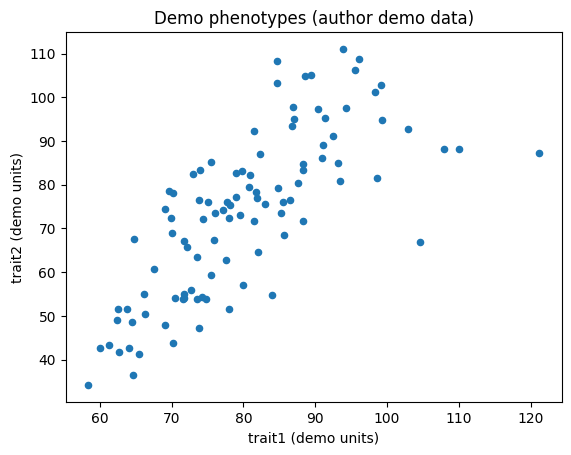

In [ ]:
import pandas as pd, pathlib

base = pathlib.Path("/content/MVBLUP/data")
pheno = pd.read_csv(base / "Phenotype.txt", sep=r"\s+")
ids = pd.read_csv(base / "train_test_id.txt", sep=r"\s+")  # file has a header row
print("Phenotype columns:", list(pheno.columns), "shape:", pheno.shape)
print(pheno.head(3).to_string(index=False))
print("\ntrain_test_id:", ids.shape, "->", ids.iloc[:, -1].value_counts().to_dict())
for i in range(1, 9):
    df = pd.read_csv(base / f"Multi_view{i}.txt", sep=r"\s+", index_col=0)
    assert df.shape[0] == 100, f"view {i}: unexpected rows {df.shape}"
    print(f"Multi_view{i}: {df.shape[0]} individuals x {df.shape[1]} features")
ax = pheno.plot.scatter(x=pheno.columns[1], y=pheno.columns[2], title="Demo phenotypes (author demo data)")
ax.set_xlabel(f"{pheno.columns[1]} (demo units)"); ax.set_ylabel(f"{pheno.columns[2]} (demo units)")
import matplotlib.pyplot as plt; plt.show()

### Run the authors' demo (core method)

This executes the verbatim author pipeline for **trait 1**: `similarity_inner_product` → per-view standardized inner products; `MVBLUP_weights` → differential evolution (population 40, CR 0.5, Mu 0.5, bounds [0,1], early-stop threshold 1e-4, ≤50 iterations, 5-fold CV fitness with `rrBLUP::kin.blup`, seed 121) → `MVBLUP_PreTest` → accuracy on the held-out test set; `plot_learning` → learning-curve figures. This is the longest cell (paper reports 28–284 s on larger datasets; expect a few minutes here). / 日本語: 著者のデモ（形質1）をそのまま実行します。差分進化による重み学習が本体で、数分かかります。

In [ ]:
import subprocess, time

t0 = time.time()
r = subprocess.run(
    ["/usr/bin/Rscript", "/content/MVBLUP/R/demo_MVBLUP.patched.R"],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True, timeout=3600,
)
print(f"Rscript exit={r.returncode} in {time.time()-t0:.1f} s")
if r.stderr:
    open("/content/MVBLUP/res/run_stderr.log", "w").write(r.stderr)
if r.returncode != 0:
    print("--- R stderr (tail) ---")
    print(r.stderr[-3000:])
    raise RuntimeError("demo_MVBLUP.R failed; see R stderr above")
print(r.stdout[-2000:] if r.stdout else "(no stdout)")

Rscript exit=0 in 177.0 s
(no stdout)


### Results: learned weights, convergence, and test accuracy

Show the author demo's own outputs: the optimal per-view weights and iteration count, the test-set accuracy table, and the two learning-curve figures written to `res/` by the author `plot.R`. The **Optimal weight** figure is shown first; the accuracy is the Pearson correlation between predicted and observed trait-1 values of the 20 test individuals. / 日本語: 学習された各ビューの最適重み・収束反復数・テスト精度（20個体の観測値と予測値の相関）と、著者plot.Rが生成する学習曲線を表示します。

MVBLUP information (optimal weights, iterations):
parameters              values
   View1_W   0.220609725176061
   View2_W    0.16596051540092
   View3_W                   0
   View4_W                   1
   View5_W 0.00883854373302029
   View6_W  0.0295713010077669
   View7_W    0.89443516400172
   View8_W   0.640255531668487
      iter                  46
     Trait              trait1

MVBLUP test accuracy (last row = Accuracy):
    name     value
sample39 81.016142
sample15 74.711987
Accuracy  0.945943


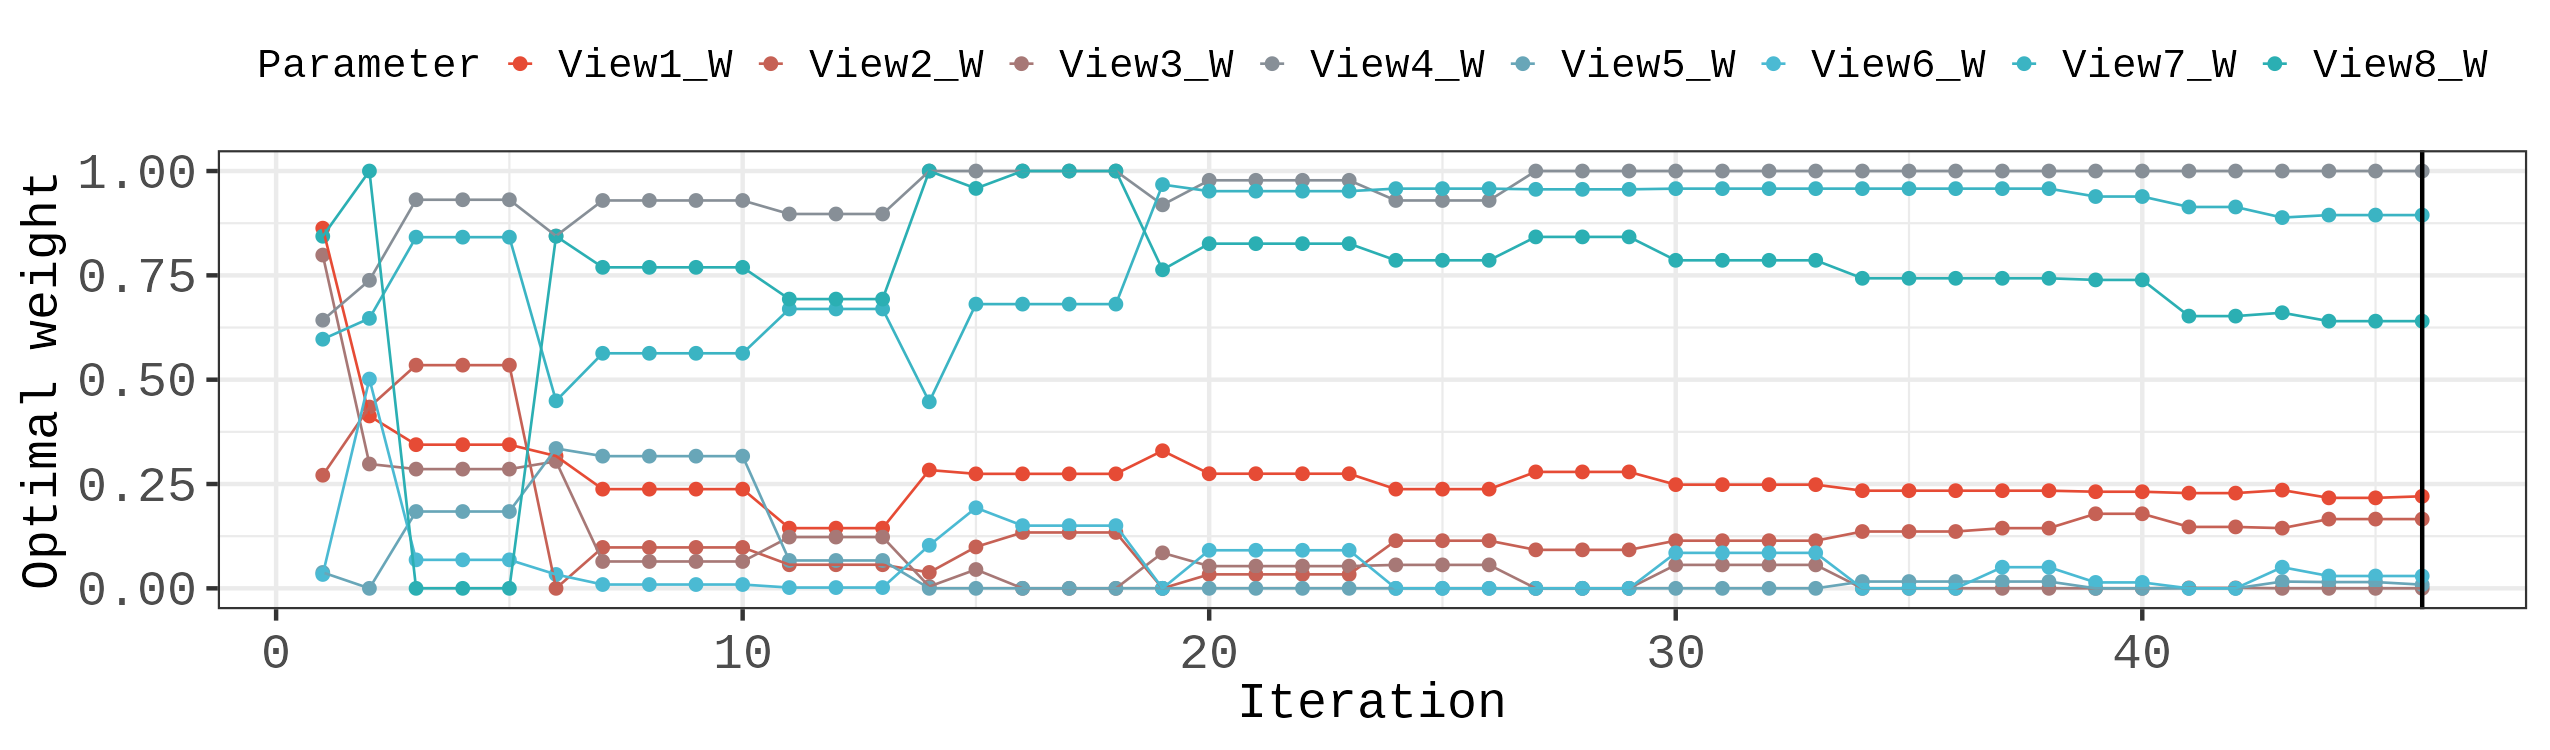

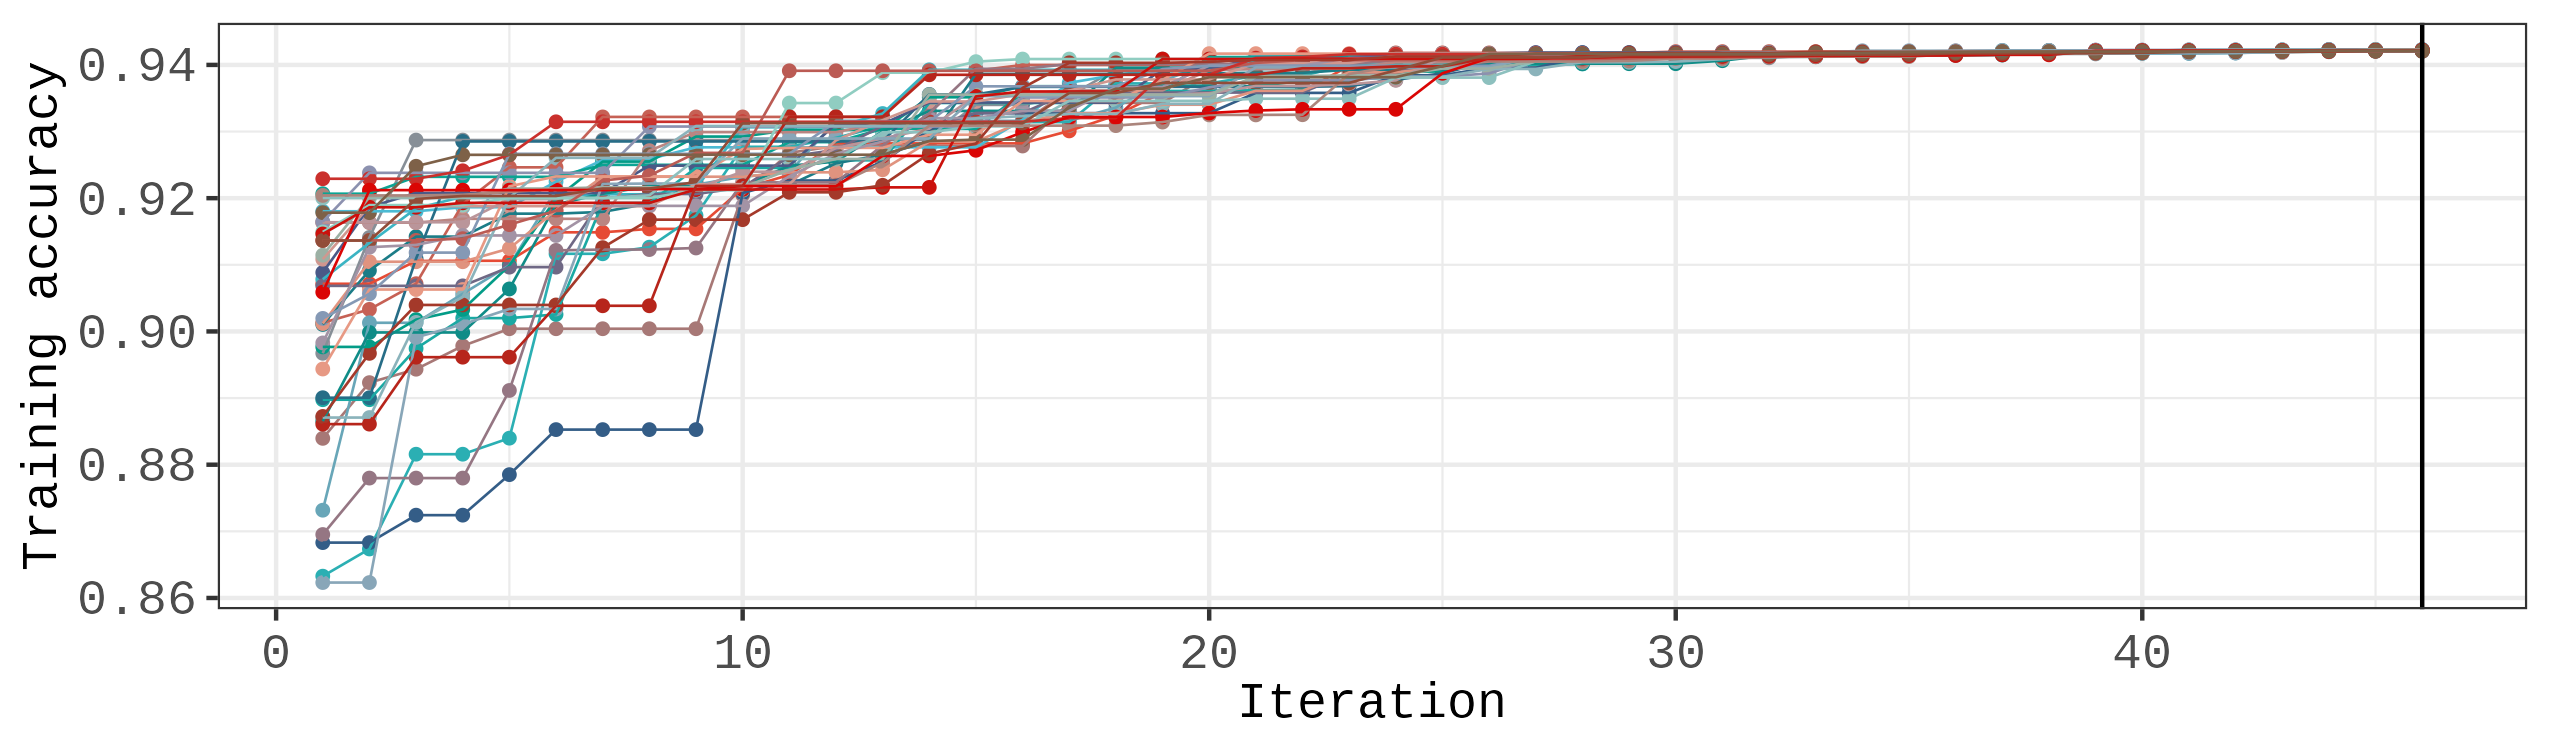

In [ ]:
import pandas as pd, pathlib
from IPython.display import Image, display

res = pathlib.Path("/content/MVBLUP/res")
info = pd.read_csv(res / "trait1-MVBLUP_information.txt", sep=r"\s+")
print("MVBLUP information (optimal weights, iterations):")
print(info.to_string(index=False))
acc = pd.read_csv(res / "trait1-MVBLUP_accuracy.txt", sep=r"\s+")
print("\nMVBLUP test accuracy (last row = Accuracy):")
print(acc.tail(3).to_string(index=False))
display(Image(filename=str(res / "trait1-Optimal weight.png")))
display(Image(filename=str(res / "trait1-Training_Accuracy.png")))

### Compare with the authors' reference demo outputs

The repository ships the authors' own demo result files under `res/` (fetched earlier). A close match of the optimal weights and accuracy confirms the pinned pipeline runs equivalently in this runtime. Small differences are expected only if package versions change numerics; a large difference would indicate a broken run. / 日本語: リポジトリ同梱の著者参照結果と学習済み重み・精度を比較し、再現性を確認します。

In [ ]:
import pandas as pd, pathlib
res = pathlib.Path("/content/MVBLUP/res")
ref_dir = pathlib.Path("/content/MVBLUP/res_reference")  # author repo res/ files, fetched earlier
ours_info = pd.read_csv(res / "trait1-MVBLUP_information.txt", sep=r"\s+")
ref_info = pd.read_csv(ref_dir / "trait1-MVBLUP_information.txt", sep=r"\s+")
def read_acc(p):
    lines = pathlib.Path(p).read_text().strip().splitlines()
    df = pd.DataFrame([l.split() for l in lines[1:]], columns=["row", "name", "value"])
    df["value"] = df["value"].astype(float)
    return df
ref_acc = read_acc(ref_dir / "trait1-MVBLUP_accuracy.txt")
ours_acc = read_acc(res / "trait1-MVBLUP_accuracy.txt")
w_ours = ours_info[~ours_info["parameters"].isin(["iter", "Trait"])].set_index("parameters")["values"].astype(float)
w_ref = ref_info[~ref_info["parameters"].isin(["iter", "Trait"])].set_index("parameters")["values"].astype(float)
cmp = pd.DataFrame({"this_run": w_ours, "author_demo_res": w_ref})
cmp["abs_diff"] = (cmp["this_run"] - cmp["author_demo_res"]).abs()
print(cmp.to_string())
acc_ours = float(ours_acc.tail(1)["value"].iloc[0]); acc_ref = float(ref_acc.tail(1)["value"].iloc[0])
print(f"\ntest accuracy: this run={acc_ours:.4f}, author res file={acc_ref:.4f}, |diff|={abs(acc_ours-acc_ref):.4f}")

            this_run  author_demo_res  abs_diff
parameters                                     
View1_W     0.220610         0.220610       0.0
View2_W     0.165961         0.165961       0.0
View3_W     0.000000         0.000000       0.0
View4_W     1.000000         1.000000       0.0
View5_W     0.008839         0.008839       0.0
View6_W     0.029571         0.029571       0.0
View7_W     0.894435         0.894435       0.0
View8_W     0.640256         0.640256       0.0

test accuracy: this run=0.9459, author res file=0.9459, |diff|=0.0000


### Save a small results export

Write a CSV copy of this run's weights/accuracy next to the author outputs so learners can inspect it without re-running. / 日本語: 本実行の重み・精度をCSVとして保存します。

In [ ]:
import pandas as pd, pathlib
res = pathlib.Path("/content/MVBLUP/res")
info = pd.read_csv(res / "trait1-MVBLUP_information.txt", sep=r"\s+")
def read_acc(p):
    lines = pathlib.Path(p).read_text().strip().splitlines()
    df = pd.DataFrame([l.split() for l in lines[1:]], columns=["row", "name", "value"])
    df["value"] = df["value"].astype(float)
    return df
acc = read_acc(res / "trait1-MVBLUP_accuracy.txt")
out = pathlib.Path("/content/MVBLUP/mvblup_trait1_summary.csv")
info.assign(source="this run").to_csv(out, index=False)
acc.assign(source="this run").to_csv(out, mode="a", index=False, header=False)
print("saved:", out)
print(open(out).read()[:800])

saved: /content/MVBLUP/mvblup_trait1_summary.csv
parameters,values,source
View1_W,0.220609725176061,this run
View2_W,0.16596051540092,this run
View3_W,0,this run
View4_W,1,this run
View5_W,0.00883854373302029,this run
View6_W,0.0295713010077669,this run
View7_W,0.89443516400172,this run
View8_W,0.640255531668487,this run
iter,46,this run
Trait,trait1,this run
"""1""","""sample17""",71.3280282457116,this run
"""2""","""sample57""",65.7344670093862,this run
"""3""","""sample94""",88.38075775524,this run
"""4""","""sample76""",96.0788304948568,this run
"""5""","""sample86""",96.2770784566742,this run
"""6""","""sample9""",73.841511103457,this run
"""7""","""sample64""",84.7869637283493,this run
"""8""","""sample53""",79.9523574854787,this run
"""9""","""sample83""",87.7069752017004,this run
"""10""","""sample44""",81.360038238777,this run
"


## Interpretation and limitations

- This run executes the **authors' own R demo, verbatim**, pinned at commit `137b119a6951c0559ae4c1f98d3f2fe21c40eecb`, on their bundled 8-view × 100-individual demo data (trait 1). Optimal view weights, the DE convergence iteration, test accuracy, and learning curves are the demo's genuine outputs.
- The demo matrices are small synthetic/illustrative data; the accuracy here **does not** validate the paper's published dataset-level results (Tomato332/Rice210/Maize368/Maize282 pipelines were not run).
- The published JGG version of record (52(6):839–847) is subscription-only; methods here follow the matching bioRxiv v1 preprint as documented in the prior investigation. Supplementary S1–S4/Table S1 were not inspected.
- The repository has no LICENSE file; reuse/redistribution conditions are unverified.
- 日本語: 本ノートブックは著者提供Rデモをそのまま実行した部分再現です。デモ行列は小規模な例示データであり、論文の公開データセット水準の結果を検証するものではありません。JGG版は購読限定のため、対応するbioRxiv v1プレプリントの手法に基づきます。リポジトリにLICENSEはありません。

**Validation record:** executed end-to-end on a fresh Colab CPU runtime (see saved outputs above); the comparison cell checks this run against the authors' shipped `res/` reference files.